[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/storopoli/ciencia-de-dados/main?filepath=notebooks%2FAula_19_Redes_Neurais_Convolucionais_com_PyTorch.ipynb)
<br>
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/storopoli/ciencia-de-dados/blob/main/notebooks/Aula_19_Redes_Neurais_Convolucionais_com_PyTorch.ipynb)

# Redes Neurais Convolucionais com PyTorch

**Objetivos**: Aprender Redes Neurais Convolucionais (_Convolution Neural Networks_ - CNN) usando a biblioteca `PyTorch`.

> Observação: Algumas imagens foram adaptadas de [Adventures in Machine Learning](https://adventuresinmachinelearning.com/convolutional-neural-networks-tutorial-in-pytorch/) (Licença CC-BY-SA).

## PyTorch

[**PyTorch**](https://www.pytorch.org/) é uma biblioteca de código aberto para aprendizado de máquina aplicável a uma ampla variedade de tarefas. Foi criada pelo **Facebook** em 2016 e é a principal biblioteca para criação e treinamento de redes neurais artificiais. A API toda é escrita em Python mas é executada em C++ na CPU ou em CUDA/ROCM na GPU.

No momento que eu escrevo esse tutorial (Abril de 2021), PyTorch está superando o TensorFlow (Google) em desempenho e adoção de uso. Isso acontece tanto na [academia](http://horace.io/pytorch-vs-tensorflow/) (mensurado pela adoção de artigos científicos nos principais encontros científicos de Aprendizagem Profunda e Aprendizagem de Máquina) quanto na [indústria](https://www.infoworld.com/article/3597904/why-enterprises-are-turning-from-tensorflow-to-pytorch.html) (mensurado pela adoção de grandes e renomadas empresas de tecnologia).

### Atualização (Junho 2022):

TensorFlow está morto, Vida Longa ao PyTorch: [Google lost the battle for machine learning to Meta, insiders say. Now it's betting the future of its own products on a new internal AI project.](https://www.businessinsider.com/facebook-pytorch-beat-google-tensorflow-jax-meta-ai-2022-6).

> Now, under the shadow of PyTorch, Google has been quietly building out a machine learning framework, called JAX (at one point an acronym for "Just After eXecution," but officially no longer stands for anything), that many see as the successor to TensorFlow.

Meus comentários: JAX é mais um backend de _autodiff_ do que uma biblioteca de redes neurais.
Ou seja tem um uso muito mais amplo que PyTorch.
Por exemplo, como um amostrador Monte Carlo de correntes ou cadeias Markov (_Markov Chain Monte Carlo_ - MCMC).

## Imagens e Filtros

Todo dado estruturado e não-esturutado é representado como matrizes no computador.
Veja o caso de imagens.
Elas são literalmente matrizes multidimensionais.

* Uma imagem colorida é uma Array de dimensão $X \times Y \times 3$:
    * $X$ = quantidade de pixels no eixo horizontal
    * $Y$ = quantidade de pixels no eixo vertical
    * $3$ = são 3 canais de cores - **R**ed, **G**reen e **B**lue

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/images_as_matrix.png?raw=1" alt="Row vs Cols" style="width: 500px;"/>

#### Convoluções

Em matemática **[convolução](https://pt.wikipedia.org/wiki/Convolu%C3%A7%C3%A3o) é um operador linear** que, a partir de **duas funções dadas**, **resulta numa terceira que mede a soma do produto dessas funções ao longo da região** subentendida pela superposição delas em função do deslocamento existente entre elas.

A notação para a convolução de $f$ e $g$ é $f*g$. Ela é definida como a integral do produto de uma das funções por uma cópia deslocada e invertida da outra; a função resultante $h$ depende do valor do deslocamento. Se $x$ for a variável independente e $u$, o deslocamento, a fórmula pode ser escrita como:

$$(f * g) (x) = h(x) = \int_{-\infty}^{\infty} f(u) \cdot g(x-u) du$$

Existe ainda uma definição de **convolução para funções de domínio discreto**, dada por

$$(f * g) (k) = h(k)= \sum_{j=0}^{k} f(j) \cdot g(k-j)$$

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/convolution.gif?raw=1" alt="Row vs Cols" style="width: 400px;"/>

Inclusive, convoluções, onde a "máquina" aprende os filtros (os números que vão dentro da matriz), é a base das redes neurais que detectam objetos!

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/deeplearning_convolutions.gif?raw=1" alt="Deep Learning Convolutions" style="width: 600px;"/>

## O que é uma Rede Neural Artificial?

Redes neurais artificiais (RNAs) são modelos computacionais inspirados pelo sistema nervoso central (em particular o cérebro) que são capazes de realizar o aprendizado de máquina bem como o reconhecimento de padrões. Redes neurais artificiais geralmente são apresentadas como sistemas de "neurônios interconectados, que podem computar valores de entradas", simulando o comportamento de redes neurais biológicas.

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/redes_neurais.jpeg?raw=1" alt="redes neurais" style="width: 500px;"/>

## Como a rede neural aprende?

Em cada neurônio há uma função de ativação (*activation function*) que processa uma combinação linear entre _inputs_ e pesos sinápticos, gerando assim um sinal de saída.

A informação flui da *input layer* para as *hidden layers* e por fim para a *output layer*. Nesse fluxo os inputs de dados da *input layer* são alimentados para os neurônios das *hidden layers* que por fim alimentam o neurônio final da *output layer*.

A primeira passada de informação (propagação) pela rede é geralmente feita com parâmetros aleatórios para as funções de ativação dos neurônios.

Ao realizar a propagação, chamada de *feed forward*, temos sinais de saídas nos neurônios da output layer.

No fim da propagação, a função custo (uma métrica de erro) é calculada e o modelo então ajusta os parâmetros dos neurônios na direção de um menor custo (por meio do gradiente - derivada multivariada).

Assim uma nova propagação é gerada e a numa nova função custo e calculada. Assim como é realizado a atualização dos parâmetros dos neurônios.

O nome desse algoritmo é **Retro-propagação** (*Backpropagation*). E cada vez que ele é executado denomina-se como época (*epoch*). E quandos as épocas estabelecidas se encerram, a rede neural encerra o seu treinamento/aprendizagem.

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/backpropagation.gif?raw=1" alt="backpropagation" style="width: 500px;"/>

#### Por que Redes Neurais Convolucionais?
As Redes Neurais Convolucionais têm a capacidade de **extrair automaticamente características dos padrões a serem aprendidos** (por meio das camadas de convolução), tarefa que necessariamente tem que ser implementada separadamente quando se emprega uma Rede Neural padrão ("vanilla", _**M**ulti**l**ayer **P**erceptron_ - MLP) ou um outro classificador convencional (por exemplo, _**S**upport **V**ector **M**achine_ - SVM)


#### O que muda numa Rede Neural Convolucional?

**Nada**.

Apenas que a rede neural possui um maior número de parâmetros pois precisa aprender todos os parâmetros dos filtros e convoluções que ocorrem em algumas de suas camadas internas.

### Camadas Necessárias para Convolução

As redes neurais convolucionais se distinguem de outras redes neurais por seu desempenho superior com dados de imagem, voz ou áudio. Elas têm três tipos principais de camadas, que são:

* Camada Convolucional
* Camada de _Pooling_
* Camada de Neurônios Totalmente Conectados (também chamado de _Fully Connected_ ou _Dense_)


#### Camadas de Convolução (_Convolution Layers_)

Isto é uma camada para uma "janela" ou "filtro" deslizante que passamos pela imagem.
Essa "janela" aplica um certo peso aos neurônios (pixels) adjacentes de uma certa vizinhança de pixels.

Filtro $2 \times 2$ com todos os pesos igual a $0.5$:

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/moving-filter.webp?raw=1" alt="filtro convolução 2x2" style="width: 500px;"/>

$$\begin{align}
 out_1 &= 0.5 in_1 + 0.5 in_2 + 0.5 in_6 + 0.5 in_7 \\
 &= 0.5 \times 2.0 + 0.5 \times 3.0 + 0.5 \times 2.0 + 0.5 \times 1.5  \\
 &= 4.25 \\
 out_2 &= 0.5 in_2 + 0.5 in_3 + 0.5 in_7 + 0.5 in_8 \\
 &= 0.5 \times 3.0 + 0.5 \times 0.0 + 0.5 \times 1.5 + 0.5 \times 0.5  \\
 &= 2.5 \\
 \end{align}$$

Na rede neural este filtro funciona assim quando compararmos com relação a camada anterior (_inputs_):

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/moving-filter-node-diagram.webp?raw=1" alt="filtro convolução 2x2" style="width: 300px;"/>

#### Camadas de _Pooling_

Uma outra técnica de "janela" ou "filtro" deslizante, mas ao invés de aplicar pesos, aplica uma função estatística sobre os conteúdos da sua "janela".

A função estatística mais comum é o máximo `max()`.
Essa é chamada de _max pooling_.

##### Duas vantagens:

- Reduz o número de parâmetros do modelo por um processo chamado _down-sampling_
- Faz com que a detecção de atributos seja mais robusta à mudanças na orientação do objeto e mudanças de escalas

_Max pooling_ com _padding_:

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/max-pooling.webp?raw=1" alt="Max Pooling" style="width: 500px;"/>

#### Juntanto todas as camadas

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/typical_cnn.webp?raw=1" alt="Rede Neural Convolucional Típica" style="width: 500px;"/>

### Estruturação dos módulos de PyTorch

```python
import torch
```
* [`torch.Tensor`](https://pytorch.org/docs/stable/tensors.html) - Tensores (arrays N-D)
* [`torch.nn`](https://pytorch.org/docs/stable/nn.html) - Redes Neurais (_**N**eural **N**etworks_)
* [`torch.optim`](https://pytorch.org/docs/stable/optim.html) - Otimização (_**Optim**ization_)
* [`torch.data`](https://pytorch.org/docs/stable/data.html) - *Datasets* e Ferramentas de Streaming de Dados
* [`torch.autograd`](https://pytorch.org/docs/stable/autograd.html) - Diferenciação Automática (_**Auto**matic Differentiation_)
* [`torch.vision`](https://pytorch.org/docs/stable/torchvision/index.html) - Ferramentas de Manipulação de Imagens e Visão Computacional
* [`torch.audio`](https://pytorch.org/audio/stable/index.html) - Ferramentas de Manipulação de Áudio
* [`torch.jit`](https://pytorch.org/docs/stable/jit.html) - Compilação _**j**ust-**i**n-**t**ime_ de modelos PyTorch em binários


### `torch.Tensor`

* `NumPy` - `np.ndarray`
* `pandas` - `pd.Series` e `pd.DataFrame`
* `PyTorch` - `torch.Tensor`

## Exemplo com o [MNIST](https://en.wikipedia.org/wiki/MNIST_database)

O dataset **MNIST** (_**M**odified **N**ational **I**nstitute of **S**tandards and **T**echnology_) é um clássico de Deep Learning. São imagens preto e branco de dígitos de 0 a 9 de formato 28x28 pixels (784 pixels)

Contém 60.000 imagens de treino e 10.000 de teste e é um padrão de benchmark de modelos (acho que "foi", não é tão usado assim mais)


<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/MNIST.png?raw=1" alt="MNIST" style="width: 500px;"/>

O pacote `torchvision` do `PyTorch` tem integrado já o dataset MNIST:

In [7]:
import torchvision
from torchvision import transforms

# MNIST dataset
#root_path = '/home/storopoli/Downloads' # mude isso no Colab se necessário
root_path = '/mnt/Dados/Projetos/LIPAI/data'

# Pequena transformação para tensores e normalizando o tamanho
trans = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

# Train/Test Datasets
train_dataset = torchvision.datasets.MNIST(root=root_path, train=True, transform=trans, download=True)
test_dataset = torchvision.datasets.MNIST(root=root_path, train=False, transform=trans)

In [8]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: /mnt/Dados/Projetos/LIPAI/data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [9]:
test_dataset

Dataset MNIST
    Number of datapoints: 10000
    Root location: /mnt/Dados/Projetos/LIPAI/data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

Para controlar como que os dados são inseridos no modelo e, logo, o Batch Size é preciso implementar um [`torch.utils.data.DataLoader()`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

Argumentos do `DataLoader()`:

* **`dataset`**: um `Dataset` PyTorch
    * tem [vários tipos](https://pytorch.org/docs/stable/data.html)
    * no nosso exemplo vou usar um simples [`TensorDataset`](https://pytorch.org/docs/stable/_modules/torch/utils/data/dataset.html#TensorDataset) que é um wrapper de `np.ndarray` e `pd.Series` para `torch.Tensor`)
* **batch_size**: `int` - tamanho do Batch Size, padrão é 1
* **shuffle**: `bool` - se vai embaralhar os dados antes de enviar em batches ao modelo, padrão é `False`. Recomendo usar `shuffle=True`

In [10]:
from torch.utils.data import DataLoader

batch_size=32

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

#### [Camadas de Convolução (_Convolution Layers_)](https://pytorch.org/docs/stable/nn.html#convolution-layers)

* [`nn.Conv1d`](https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html#torch.nn.Conv3d): convolução 1-D.
* [`nn.Conv2d`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html): convolução 2-D.
* [`nn.Conv3d`](https://pytorch.org/docs/stable/generated/torch.nn.Conv3d.html): convolução 3-D.

#### [Camadas de _Pooling_](https://pytorch.org/docs/stable/nn.html#pooling-layers)

* [`nn.MaxPool1d`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool1d.htm): 1-D _max pooling_.
* [`nn.MaxPool2d`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.htm): 2-D _max pooling_.
* [`nn.MaxPool3d`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool3d.htm): 3-D _max pooling_.

### Qual a rede neural convolucional que vamos criar para o MNIST?

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/MNIST-CNN.webp?raw=1" alt="MNIST CNN" style="width: 700px;"/>

## Como construir sua rede neural convolucional no PyTorch

Construir redes neurais com o **PyTorch** é fácil.

Temos que criar uma Rede Neural a partir de uma classe [`nn.Module()`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html?highlight=module#torch.nn.Module) e criar um construtor com o método `__init__()` e implementar todas as layers e propagações desejadas com o método `forward()`.

In [11]:
import torch.nn as nn

In [12]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc1 = nn.Sequential(
            nn.Linear(7 * 7 * 64, 1000),
            nn.ReLU())
        self.fc2 = nn.Linear(1000, 10)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc1(out)
        out = self.fc2(out)
        return out

# Instancia o Model()
model = ConvNet()

print(model)

ConvNet(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=3136, out_features=1000, bias=True)
    (1): ReLU()
  )
  (fc2): Linear(in_features=1000, out_features=10, bias=True)
)


Quantos paramêtros temos?

In [13]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

count_parameters(model)

3199106

## Como treinar sua rede neural no PyTorch

Uma vez especificado e instanciado o modelo, podemos manipulá-lo de maneira dinâmica.
Escolhemos a função custo (`loss_fn`) como `nn.CrossEntropyLoss()` e também a taxa de aprendizagem $\eta$ em `1e-6` e a quantidade de épocas a serem treinadas (`epochs`):

```python
model = Sua_rede_neural()
loss_fn = nn.CrossEntropyLoss()
learning_rate = 1e-6
epochs = 100

# Instânciar o Otimizador Adam
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# For-loop de treino
for epoch in range(epochs): # para cada época
    for (images, labels) in train_loader: # para cada batch
        # Gera a propagação (feed forward)
        outputs = model(images)
        
        # Calcula a função-custo
        loss = loss_fn(outputs, labels)
        
        # Retro-propagação (Backprop) e a otimização com Adam
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
```

In [14]:
from torch.optim import Adam

# Hiperparâmetros
loss_fn = nn.CrossEntropyLoss()
learning_rate = 0.001
epochs = 6

# Instânciar o Otimizador Adam
optimizer = Adam(model.parameters(), lr=learning_rate)

### OBSERVAÇÃO

Esta rede neural possui muitos parâmetros.
Aproximadamente 3 milhões e 200 mil paramêtros!
Não tente rodar isso sem ser usando uma GPU!
O Google Colab te dá uma GPU de graça.
Clique no botão abaixo para abrir este notebook no Google Colab.
Não esqueça de trocar sua `Runtime` de `None` para `GPU`.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/storopoli/ciencia-de-dados/blob/main/notebooks/Aula_19_Redes_Neurais_Convolucionais_com_PyTorch.ipynb)

In [15]:
# Isto tem que retornar True
import torch
torch.cuda.is_available()

False

In [16]:
# Sua GPU
#torch.cuda.get_device_name()


### Como estou rodando no PyCharm, Linux e usando uma placa AMD:

1. Instalei ONNX Runtime
```pip install onnxruntime```

2.  PyTorch no CPU
```pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu```

Foi tranquilo.

In [17]:
import onnxruntime as ort

# Mostra todos os providers disponíveis
print("Providers disponíveis:", ort.get_available_providers())

# Cria sessão tentando usar GPU
# Se tiver OpenCL vai aparecer 'OpenCLExecutionProvider'
# Se não, vai usar CPU mesmo
providers = ort.get_available_providers()
print("Usando:", providers[0])

Providers disponíveis: ['AzureExecutionProvider', 'CPUExecutionProvider']
Usando: AzureExecutionProvider


In [18]:
# Treinar o Modelo
total_step = len(train_loader) # quantos batches eu tenho

# Listas vazias
loss_list = []
acc_list = []

for epoch in range(epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Gera a propagação (feed forward)
        outputs = model(images)

        # Calcula a função-custo
        loss = loss_fn(outputs, labels)
        loss_list.append(loss.item())

        # Retro-propagação (Backprop) e a otimização com Adam
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Acurácia
        total = labels.size(0)
        _, predicted = torch.max(outputs.data, 1)
        correct = (predicted == labels).sum().item()
        acc_list.append(correct / total)
        if (i + 1) % 100 == 0:
            print(f"Época [{epoch+1}/{epochs}], Step [{i+1}/{total_step}], Custo: {round(loss.item(), 3)}, Acurácia: {round((correct / total) * 100, 3)}")

Época [1/6], Step [100/1875], Custo: 0.313, Acurácia: 93.75
Época [1/6], Step [200/1875], Custo: 0.117, Acurácia: 96.875
Época [1/6], Step [300/1875], Custo: 0.268, Acurácia: 93.75
Época [1/6], Step [400/1875], Custo: 0.079, Acurácia: 96.875
Época [1/6], Step [500/1875], Custo: 0.018, Acurácia: 100.0
Época [1/6], Step [600/1875], Custo: 0.011, Acurácia: 100.0
Época [1/6], Step [700/1875], Custo: 0.175, Acurácia: 93.75
Época [1/6], Step [800/1875], Custo: 0.092, Acurácia: 96.875
Época [1/6], Step [900/1875], Custo: 0.077, Acurácia: 96.875
Época [1/6], Step [1000/1875], Custo: 0.01, Acurácia: 100.0
Época [1/6], Step [1100/1875], Custo: 0.021, Acurácia: 100.0
Época [1/6], Step [1200/1875], Custo: 0.004, Acurácia: 100.0
Época [1/6], Step [1300/1875], Custo: 0.043, Acurácia: 96.875
Época [1/6], Step [1400/1875], Custo: 0.102, Acurácia: 96.875
Época [1/6], Step [1500/1875], Custo: 0.121, Acurácia: 96.875
Época [1/6], Step [1600/1875], Custo: 0.025, Acurácia: 96.875
Época [1/6], Step [1700/18

### Acurácia do Modelo

Usar o comando `model.eval()`

Para a métrica acurácia, retorna um score de acurácia `float` entre $0$ e $1$

In [19]:
model.eval() # coloca o modelo em modo de avaliação (sem calcular gradientes)

with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        # Feed-forward com as imagens de teste
        outputs = model(images)

        # gera predições usando a função max()
        _, predicted = torch.max(outputs.data, 1)

        # Acumula total e corretas
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Acurácia do Modelo em 10k imagens de teste: {round((correct / total) * 100, 3)}")

Acurácia do Modelo em 10k imagens de teste: 99.08


# Estudo prático

Compreender o processo de construção, treinamento e avaliação de uma Rede Neural Convolucional utilizando o dataset
MNIST. Observe a arquitetura proposta, o carregamento dos dados, a etapa de treinamento e a avaliação do modelo.

1) O notebook verifica a disponibilidade da GPU com torch.cuda.is_available(), mas o código de treinamento não move explicitamente o modelo e os dados para o dispositivo selecionado. Defina uma variável device no início do código e utilize o método .to(device) para enviar o modelo e cada lote de tensores (imagens e rótulos) para a GPU durante o loop de treinamento e avaliação.

In [21]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.optim import Adam

# 1. Seleciona o dispositivo disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")

# 2. Datasets e DataLoaders (igual ao original)
trans = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
root_path = './data'
train_dataset = torchvision.datasets.MNIST(
    root=root_path, train=True, transform=trans, download=True)
test_dataset  = torchvision.datasets.MNIST(
    root=root_path, train=False, transform=trans)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# 3. Arquitetura (igual ao original)
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(), nn.MaxPool2d(2, 2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(), nn.MaxPool2d(2, 2))
        self.fc1 = nn.Sequential(nn.Linear(7*7*64, 1000), nn.ReLU())
        self.fc2 = nn.Linear(1000, 10)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.reshape(x.size(0), -1)
        x = self.fc1(x)
        return self.fc2(x)

# 4. Move o modelo para o device
model = ConvNet().to(device)

loss_fn      = nn.CrossEntropyLoss()
optimizer    = Adam(model.parameters(), lr=0.001)
epochs       = 6
total_step   = len(train_loader)

# 5. Loop de treino com .to(device) nos tensores
for epoch in range(epochs):
    model.train()
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)   # <-- move para GPU/CPU
        labels = labels.to(device)   # <-- move para GPU/CPU

        outputs = model(images)
        loss    = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i + 1) % 100 == 0:
            _, predicted = torch.max(outputs.data, 1)
            acc = (predicted == labels).sum().item() / labels.size(0)
            print(f"Época [{epoch+1}/{epochs}], "
                  f"Step [{i+1}/{total_step}], "
                  f"Custo: {loss.item():.4f}, "
                  f"Acurácia: {acc*100:.2f}%")

Dispositivo em uso: cpu


100.0%
100.0%
100.0%
100.0%


Época [1/6], Step [100/1875], Custo: 0.2087, Acurácia: 93.75%
Época [1/6], Step [200/1875], Custo: 0.0891, Acurácia: 100.00%
Época [1/6], Step [300/1875], Custo: 0.0284, Acurácia: 100.00%
Época [1/6], Step [400/1875], Custo: 0.0934, Acurácia: 96.88%
Época [1/6], Step [500/1875], Custo: 0.1146, Acurácia: 96.88%
Época [1/6], Step [600/1875], Custo: 0.1637, Acurácia: 93.75%
Época [1/6], Step [700/1875], Custo: 0.0260, Acurácia: 100.00%
Época [1/6], Step [800/1875], Custo: 0.0677, Acurácia: 100.00%
Época [1/6], Step [900/1875], Custo: 0.0724, Acurácia: 93.75%
Época [1/6], Step [1000/1875], Custo: 0.0979, Acurácia: 96.88%
Época [1/6], Step [1100/1875], Custo: 0.0119, Acurácia: 100.00%
Época [1/6], Step [1200/1875], Custo: 0.0510, Acurácia: 96.88%
Época [1/6], Step [1300/1875], Custo: 0.0033, Acurácia: 100.00%
Época [1/6], Step [1400/1875], Custo: 0.4847, Acurácia: 90.62%
Época [1/6], Step [1500/1875], Custo: 0.0590, Acurácia: 96.88%
Época [1/6], Step [1600/1875], Custo: 0.0207, Acurácia: 10

2) O modelo é avaliado apenas uma vez no final do treinamento, utilizando o conjunto de teste. Uma prática melhor é usar um conjunto de validação separado para monitorar o desempenho a cada época. Divida o train_dataset original em conjuntos de treino e validação usando torch.utils.data.random_split. Em seguida, adicione um loop de validação com model.eval() e torch.no_grad() dentro do loop de épocas para calcular a perda e a acurácia de validação.

In [22]:
from torch.utils.data import random_split

# Divide 60k em 50k treino + 10k validação
train_size = 50_000
val_size   = len(train_dataset) - train_size
train_data, val_data = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False)

model     = ConvNet().to(device)
optimizer = Adam(model.parameters(), lr=0.001)
loss_fn   = nn.CrossEntropyLoss()

for epoch in range(epochs):
    # --- Treino ---
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = loss_fn(outputs, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()

    # --- Validação ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs   = model(images)
            val_loss += loss_fn(outputs, labels).item()
            _, pred   = torch.max(outputs, 1)
            correct  += (pred == labels).sum().item()
            total    += labels.size(0)

    val_acc  = correct / total * 100
    val_loss /= len(val_loader)
    print(f"Época {epoch+1}: Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")

Época 1: Val Loss=0.0533, Val Acc=98.36%
Época 2: Val Loss=0.0475, Val Acc=98.63%
Época 3: Val Loss=0.0444, Val Acc=98.89%
Época 4: Val Loss=0.0495, Val Acc=98.88%
Época 5: Val Loss=0.0683, Val Acc=98.32%
Época 6: Val Loss=0.0441, Val Acc=99.04%


3) O treinamento imprime o custo e a acurácia no terminal, mas os resultados sã mais fáceis de interpretar visualmente. Armazene o histórico de perda e acurácia de treino e validação em listas. Ao final do treinamento, utilize a biblioteca matplotlib para plotar gráficos da perda e da acurácia ao longo das épocas. Isso permitirá analisar a convergência do modelo e identificar possíveis sinais de overfitting.

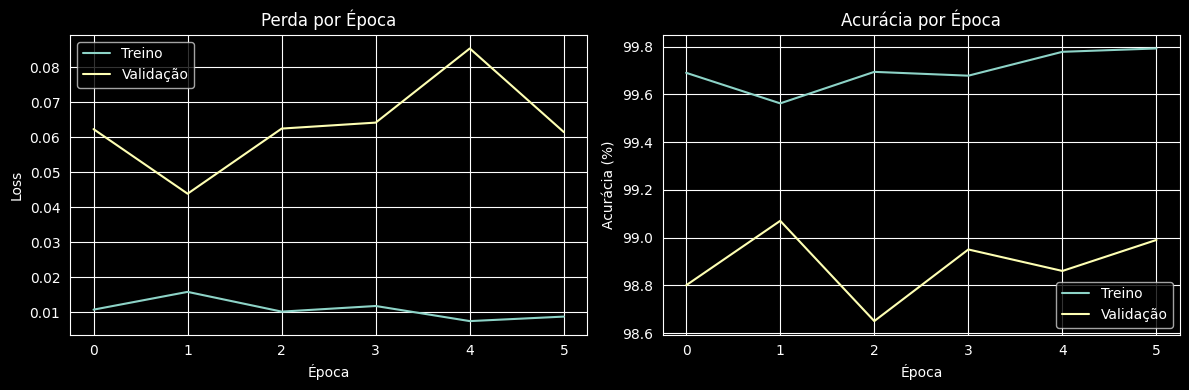

In [23]:
import matplotlib.pyplot as plt

train_losses, val_losses   = [], []
train_accs,   val_accs     = [], []

for epoch in range(epochs):
    # ---- Treino ----
    model.train()
    ep_loss, ep_correct, ep_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs  = model(images)
        loss     = loss_fn(outputs, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        ep_loss += loss.item()
        _, pred  = torch.max(outputs, 1)
        ep_correct += (pred == labels).sum().item()
        ep_total   += labels.size(0)
    train_losses.append(ep_loss / len(train_loader))
    train_accs.append(ep_correct / ep_total * 100)

    # ---- Validação ----
    model.eval()
    vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            out  = model(images)
            vl  += loss_fn(out, labels).item()
            _, p = torch.max(out, 1)
            vc  += (p == labels).sum().item()
            vt  += labels.size(0)
    val_losses.append(vl / len(val_loader))
    val_accs.append(vc / vt * 100)

# ---- Plotagem ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label="Treino")
ax1.plot(val_losses,   label="Validação")
ax1.set_title("Perda por Época"); ax1.set_xlabel("Época")
ax1.set_ylabel("Loss"); ax1.legend()

ax2.plot(train_accs, label="Treino")
ax2.plot(val_accs,   label="Validação")
ax2.set_title("Acurácia por Época"); ax2.set_xlabel("Época")
ax2.set_ylabel("Acurácia (%)"); ax2.legend()

plt.tight_layout()
plt.savefig("historico_treino.png", dpi=150)
plt.show()

4) Um ponto importante em aprendizagem profunda é salvar o modelo treinad para uso posterior. Demonstre como salvar o estado do modelo com torch.save(model.state_dict()), salvando aquele que apresentar o melhor desempenho no conjunto de validação. Mostre também como carregar esses peso em uma nova instância do modelo.

In [24]:
best_val_acc = 0.0

for epoch in range(epochs):
    # val_acc já foi calculada:

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  -> Novo melhor modelo salvo! Val Acc={val_acc:.2f}%")

# ---- Carregar o modelo salvo ----
model_loaded = ConvNet().to(device)
model_loaded.load_state_dict(torch.load("best_model.pth", map_location=device))
model_loaded.eval()
print("Modelo carregado com sucesso.")

# Verificação final no teste
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        out  = model_loaded(images)
        _, p = torch.max(out, 1)
        correct += (p == labels).sum().item()
        total   += labels.size(0)
print(f"Acurácia no teste (best model): {correct/total*100:.2f}%")

  -> Novo melhor modelo salvo! Val Acc=99.04%
Modelo carregado com sucesso.
Acurácia no teste (best model): 99.17%


5) Explore modificações na arquitetura da rede ou no processo de treinamento para tentar melhorar ainda mais os resultados. Teste diferentes otimizadores e taxas de aprendizado no modelo. Depois, descreva o que foi observado em relação ao treinamento, validação e teste. Os modelos ficaram melhores? O treinamento se tornou ma

In [25]:
import torch.optim as optim

configuracoes = [
    ("SGD  lr=0.01",  optim.SGD,  {"lr": 0.01, "momentum": 0.9}),
    ("Adam lr=1e-3",  optim.Adam, {"lr": 1e-3}),
    ("Adam lr=1e-4",  optim.Adam, {"lr": 1e-4}),
]

for nome, Otimizador, params in configuracoes:
    model_exp = ConvNet().to(device)
    opt_exp   = Otimizador(model_exp.parameters(), **params)

    for epoch in range(epochs):
        model_exp.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            out  = model_exp(images)
            loss = loss_fn(out, labels)
            opt_exp.zero_grad(); loss.backward(); opt_exp.step()

    # Avalia no conjunto de validação
    model_exp.eval()
    vc, vt = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            _, p = torch.max(model_exp(images), 1)
            vc  += (p == labels).sum().item()
            vt  += labels.size(0)
    print(f"[{nome}] Val Acc = {vc/vt*100:.2f}%")

[SGD  lr=0.01] Val Acc = 99.28%
[Adam lr=1e-3] Val Acc = 98.31%
[Adam lr=1e-4] Val Acc = 99.01%


6) Qual é a diferença entre os modos model.train() e model.eval() Por que é crucial usar model.eval() junto com torch.no_grad() durante a fase de teste e avaliação?

- `model.train()`: ativa camadas cujo comportamento depende da fase de treinamento:
    - Dropout descarta aleatoriamente neurônios para regularização.
    - BatchNorm usa as estatísticas do batch atual (média e variância calculadas on-the-fly).

- `model.eval()`: desativa esses comportamentos:
    - Dropout é desativado (todos os neurônios são usados).
    - BatchNorm usa as estatísticas acumuladas (running mean/var) calculadas durante o treino.

Por que usar `model.eval()` + `torch.no_grad()`?

Durante a avaliação não há necessidade de calcular gradientes, pois não ocorre retro-propagação. O `torch.no_grad()` instrui o PyTorch a não construir o grafo computacional, economizando memória e acelerando a inferência. Combinado com `model.eval()`, garante que as métricas avaliadas reflitam o comportamento real do modelo em produção, sem o ruído do Dropout e com as estatísticas corretas do BatchNorm.

```python
# Padrão recomendado de avaliação
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        # ... calcular métricas ...
```


7) O dataset MNIST é um ótimo ponto de partida para aprendizado, mas é considerado um problema já bastante consolidado. Após o exemplo com MNIST, explore o dataset Fashion-MNIST (60.000 imagens de treino, 10.000 de teste, imagens 28x28 em escala de cinza, distribuídas em 10 classes). Utilize esse dataset para uma nova tarefa de classificação.

In [26]:
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

trans = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))  # média/std do Fashion-MNIST
])

fashion_train = torchvision.datasets.FashionMNIST(
    root='./data', train=True, transform=trans, download=True)
fashion_test  = torchvision.datasets.FashionMNIST(
    root='./data', train=False, transform=trans)

train_data, val_data = random_split(fashion_train, [50_000, 10_000])

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=64, shuffle=False)
test_loader  = DataLoader(fashion_test, batch_size=64, shuffle=False)

# A arquitetura ConvNet é a mesma (entrada 28x28, 10 classes)
model_fashion = ConvNet().to(device)
optimizer     = Adam(model_fashion.parameters(), lr=1e-3)
loss_fn       = nn.CrossEntropyLoss()

best_val_acc = 0.0
train_hist, val_hist = [], []

for epoch in range(10):  # mais épocas pois o problema é mais difícil
    # ---- Treino ----
    model_fashion.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        out  = model_fashion(images)
        loss = loss_fn(out, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()

    # ---- Validação ----
    model_fashion.eval()
    vc, vt, vl = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            out  = model_fashion(images)
            vl  += loss_fn(out, labels).item()
            _, p = torch.max(out, 1)
            vc  += (p == labels).sum().item()
            vt  += labels.size(0)
    val_acc = vc / vt * 100
    val_hist.append(val_acc)
    print(f"Época {epoch+1:02d}: Val Loss={vl/len(val_loader):.4f}, "
          f"Val Acc={val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_fashion.state_dict(), "best_fashion.pth")

# ---- Avaliação Final ----
model_fashion.load_state_dict(
    torch.load("best_fashion.pth", map_location=device))
model_fashion.eval()
tc, tt = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _, p = torch.max(model_fashion(images), 1)
        tc  += (p == labels).sum().item()
        tt  += labels.size(0)
print(f"\nAcurácia final no teste (Fashion-MNIST): {tc/tt*100:.2f}%")

# Classes do Fashion-MNIST
classes = ['Camiseta', 'Calça', 'Pullover', 'Vestido', 'Casaco',
           'Sandália', 'Camisa', 'Tênis', 'Bolsa', 'Bota']

100.0%
100.0%
100.0%
100.0%


Época 01: Val Loss=0.3432, Val Acc=88.28%
Época 02: Val Loss=0.2615, Val Acc=90.20%
Época 03: Val Loss=0.2442, Val Acc=91.14%
Época 04: Val Loss=0.2297, Val Acc=92.00%
Época 05: Val Loss=0.2452, Val Acc=91.41%
Época 06: Val Loss=0.2448, Val Acc=92.08%
Época 07: Val Loss=0.2724, Val Acc=91.68%
Época 08: Val Loss=0.3012, Val Acc=92.09%
Época 09: Val Loss=0.3322, Val Acc=92.05%
Época 10: Val Loss=0.3481, Val Acc=91.63%

Acurácia final no teste (Fashion-MNIST): 91.43%
